In [ ]:
import torch, torch.nn as nn, torch.optim as optim
#imports pytorch for neural network layers

import torchvision.transforms as T
#crop and normalize images

from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
#feeds data into GPU in small batches

import numpy as np, matplotlib.pyplot as plt
from PIL import Image
import os
import random


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#uses cuda if it exists, uses cpu instead if there is no gpu
IMG, HOLE, EPOCHS, BS, LR = 128, 64, 100, 64, 2e-4
#size of the image
#size of the missing portion
#number of epochs
#batch size: trains on 64 images at a time
#learning rate

In [ ]:
class FlatCEDataset(Dataset):
    def __init__(self, folder_path):
        self.folder_path = folder_path
        #transforms the images to 128x128, converts them to pytorch tensors, and normalizes pixel values to be [-1,1]
        self.tfm = T.Compose([
            T.Resize((IMG, IMG)), 
            T.ToTensor(), 
            T.Normalize([.5]*3, [.5]*3)
        ])
        
        #checks if the images are in valid format
        valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
        try:
            self.files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)]
        except FileNotFoundError:
            print(f"Directory '{folder_path}' not found. Generating dummy data.")
            self.files = []
            self.n = 2000

    #prints number of images
    def __len__(self): 
        return len(self.files) if self.files else self.n

    #converts 
    def __getitem__(self, i):
        if self.files:
            img_path = os.path.join(self.folder_path, self.files[i])
            img = Image.open(img_path).convert('RGB')
            img = self.tfm(img)
        else:
            img = torch.rand(3, IMG, IMG) * 2 - 1
            
        #chooses a random coordinate in image and removes it, fills it in as black 
        #creates 2 images: image with a hole and the original

        max_idx = IMG - HOLE
        start_y = random.randint(0, max_idx)
        start_x = random.randint(0, max_idx)
        
        masked = img.clone()
        masked[:, start_y:start_y+HOLE, start_x:start_x+HOLE] = 0
        gt = img[:, start_y:start_y+HOLE, start_x:start_x+HOLE]
        
        #returns the damaged image, the missing square, the original image, and the location at which it was removed 
        return masked, gt, img, start_y, start_x


TRAIN_FOLDER = './fruit_data_separate'
TEST_FOLDER = './fruit_data_final_test' 
#loads our datasets at 64 imagaes at a time with order shuffling and drops last few images to keep batch size even
train_loader = DataLoader(FlatCEDataset(TRAIN_FOLDER), BS, shuffle=True, drop_last=True)

test_loader = DataLoader(FlatCEDataset(TEST_FOLDER), batch_size=10, shuffle=False, drop_last=False)

print(f"Training on {len(train_loader.dataset)} images.")
print(f"Testing on {len(test_loader.dataset)} images.")

NameError: name 'Dataset' is not defined

In [ ]:
class Encoder(nn.Module):
    #takes in the masked image and puts it through 5 convolutional layers
    #halves the height and width and increases features (image characteristics such as shapes and lines and colors)
    #as the images go deeper in the network, the features increase from 64 to 128 to 256 to 512 
    #but the resolution goes down significiantly because of this
    #compresses all this information into a vector
    def __init__(self):
        super().__init__()
        def blk(ci,co,s=2): return [nn.Conv2d(ci,co,4,s,1), nn.BatchNorm2d(co), nn.LeakyReLU(.2,True)]
        self.net = nn.Sequential(*blk(3,64),*blk(64,128),*blk(128,256),*blk(256,512),*blk(512,512))
        self.fc  = nn.Linear(512*4*4, 4000)
    def forward(self,x): return self.fc(self.net(x).flatten(1))


class Decoder(nn.Module):
    #takes in the 4000 numbered vector
    #reshapes it back into an image
    #uses transposed convolutional layers or deconvolutions to scale it
    #transposed convolutional layers: increases spatial dimensions of input 
    #output a 64x64 image patch
    #tanh ensures the pixels stay within [-1,1]
    def __init__(self):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(4000,512*4*4), nn.BatchNorm1d(512*4*4), nn.ReLU(True))
        def ubl(ci,co): return [nn.ConvTranspose2d(ci,co,4,2,1), nn.BatchNorm2d(co), nn.ReLU(True)]
        self.net = nn.Sequential(*ubl(512,256),*ubl(256,128),*ubl(128,64),*ubl(64,32),
                                  nn.ConvTranspose2d(32,3,3,1,1), nn.Tanh())
    def forward(self,z): return self.net(self.proj(z).view(-1,512,4,4))



#uses sigmoid function: 0 = fake | 1 = real
class Disc(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ci,co,bn=True): return [nn.Conv2d(ci,co,4,2,1),*([ nn.BatchNorm2d(co)] if bn else []),nn.LeakyReLU(.2,True)]
        self.net = nn.Sequential(*blk(3,64,False),*blk(64,128),*blk(128,256),*blk(256,512),
                                  nn.Conv2d(512,1,4,1,0), nn.Sigmoid())
    def forward(self,x): return self.net(x).view(x.size(0))

#uses adam optimizers that update network weights
#divides the LR by 10 so that it prevents the model from overfitting
#binary cross entropy loss: calculates how well the discriminator is distinguishing real from fake
#mean squared error loss: compares the generated patch to the original missing piece pixel by pixel
E, D, Dsc = Encoder().to(device), Decoder().to(device), Disc().to(device)
optG = optim.Adam(list(E.parameters())+list(D.parameters()), LR,   betas=(.5,.999))
optD = optim.Adam(Dsc.parameters(),                           LR/10, betas=(.5,.999))
bce, mse = nn.BCELoss(), nn.MSELoss()

print(f'Params  Enc+Dec: {sum(p.numel() for p in list(E.parameters())+list(D.parameters())):,}  Disc: {sum(p.numel() for p in Dsc.parameters()):,}')

Params  Enc+Dec: 75,306,467  Disc: 2,766,529


In [ ]:
history = []
print("Starting Training...")
for ep in range(1, EPOCHS+1):
    E.train(); D.train(); Dsc.train()
    gl = dl = 0
    #loops dataset in batches of 64 images
    for masked, gt, full, start_y, start_x in train_loader:
        masked, gt, full = masked.to(device), gt.to(device), full.to(device)
        #puts the masked image through the encoder/decoder
        fake = D(E(masked))
        
        # Discriminator Step
        optD.zero_grad()
        (bce(Dsc(gt),   torch.ones(BS,device=device)) +
         bce(Dsc(fake.detach()), torch.zeros(BS,device=device))).mul(.5).backward()
        #adds the real and fake loss of the reconstruction and takes the average
        #calculates the errors

        optD.step() #updates weights
        
        # Generator Step
        optG.zero_grad()
        #compares the fake patch to real patch and forces it to learn shapes and colors
        #generator feeds the fake image to discriminator and calculates loss from 1
        #fake guesses increase the loss, and so generator is forced to make the next fake look more real
        loss = .999*mse(fake,gt) + .001*bce(Dsc(fake), torch.ones(BS,device=device))
        #updates weights based on combined feedback
        loss.backward(); optG.step()
        
        # adds the losses to see average loss overtime
        gl += loss.item(); dl += 1
        
    avg = gl/dl; history.append(avg)
    if ep % 10 == 0: print(f'Epoch {ep:3d} | Average Loss: {avg:.4f}')

print('Training Complete!')

Starting Training...
Epoch  10 | Average Loss: 0.2755
Epoch  20 | Average Loss: 0.2285
Epoch  30 | Average Loss: 0.2211
Epoch  40 | Average Loss: 0.2128
Epoch  50 | Average Loss: 0.2021
Epoch  60 | Average Loss: 0.1917
Epoch  70 | Average Loss: 0.1872
Epoch  80 | Average Loss: 0.1818
Epoch  90 | Average Loss: 0.1757
Epoch 100 | Average Loss: 0.1721
Training Complete!


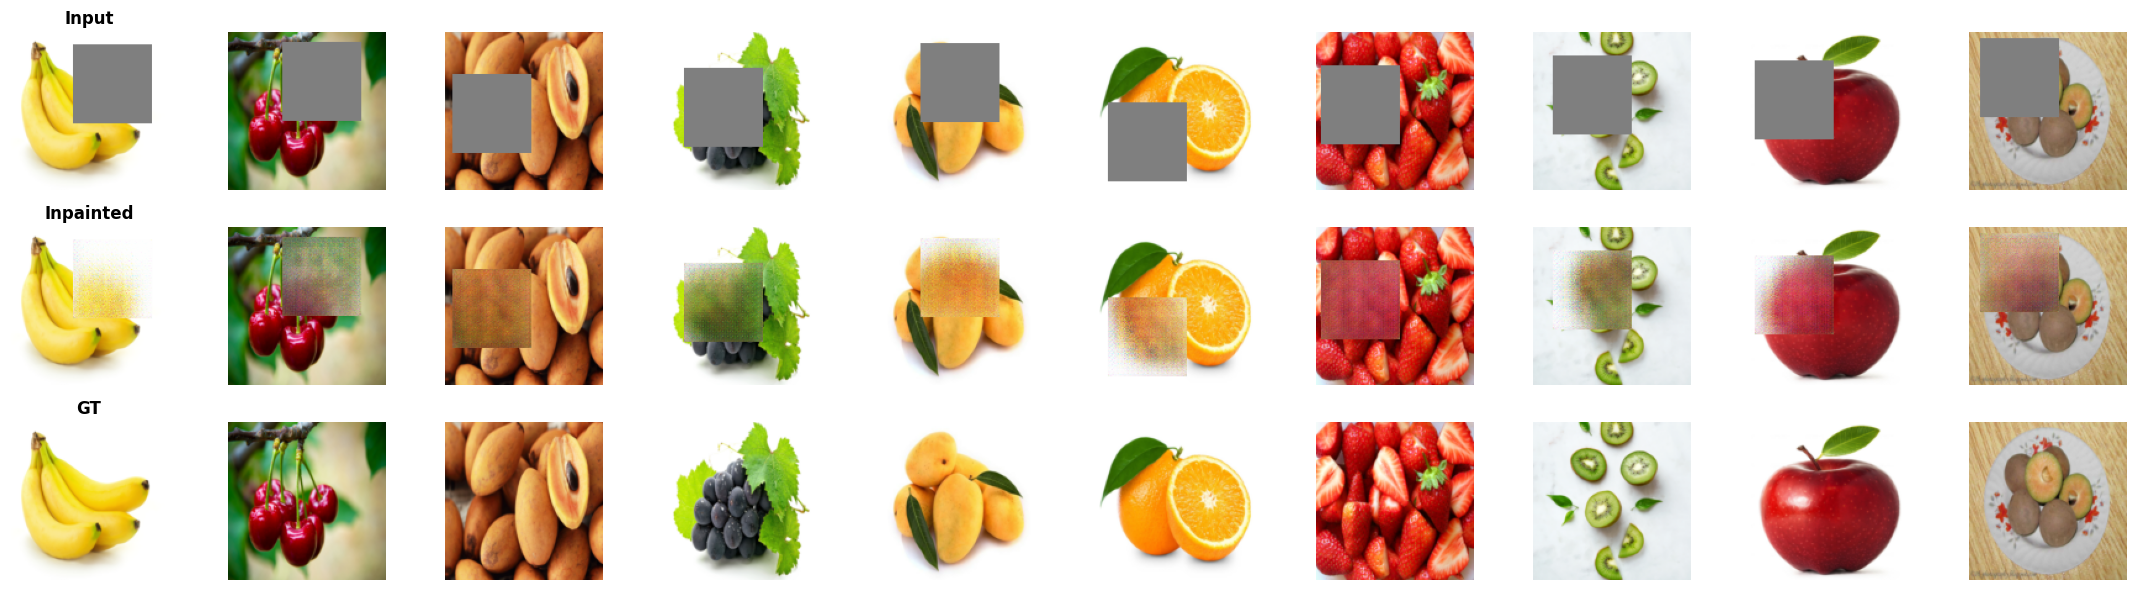

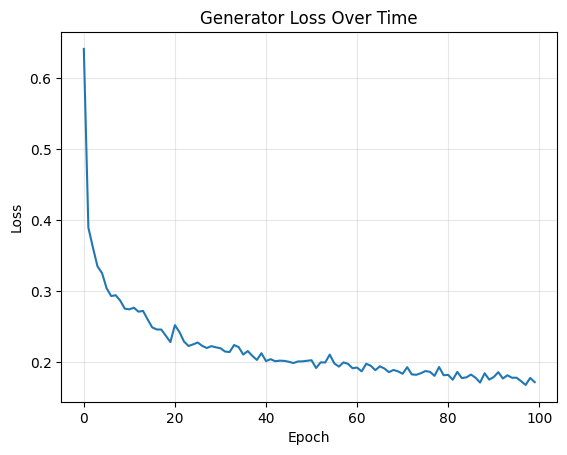

In [ ]:
E.eval(); D.eval()

masked, gt, full, start_y, start_x = next(iter(test_loader))

#brings in test images and passes them through network
with torch.no_grad(): pred = D(E(masked[:12].to(device))).cpu()

#puts masked images on blank canvas
composed = masked[:12].clone()

#pastes the model's predicted output into the empty space
for i in range(12):
    y = start_y[i].item() 
    x = start_x[i].item()
    composed[i, :, y:y+HOLE, x:x+HOLE] = pred[i]
    
#reverses normalization/bring pixels to standard range[0,1], rounds pixel values, and modifieds features to match matplotlib

dn = lambda t: (t*.5+.5).clamp(0,1).permute(1,2,0).numpy()

#plots reconstruected images 
#plots the masks, the repaired image, and the original
fig, axes = plt.subplots(3, 12, figsize=(24, 6))
for i in range(12):
    for j,(img,ttl) in enumerate(zip([masked[i],composed[i],full[i]],['Input','Inpainted','GT'])):
        axes[j,i].imshow(dn(img)); axes[j,i].axis('off')
        if i==0: axes[j,i].set_title(ttl,fontweight='bold')
plt.tight_layout()
plt.show()

#plots learning curve
#steady downwards trend shows model minimizing errors as it trains
plt.figure()
plt.plot(history)
plt.title('Generator Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=.3)
plt.show()